# 04 - Gözetimli Makine Öğrenmesi
## Uydu Telemetri Anomali Tespiti

Segment bazlı özellik matrisini kullanarak gözetimli anomali tespiti modellerini eğitmek.

### Modeller:
1. Random Forest
2. Support Vector Machine
3. XGBoost
4. MLP


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, sys
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

sys.path.insert(0, '..')
sys.path.insert(0, os.path.join('..', 'src'))
from src.models.supervised import SupervisedAnomalyDetector
from metrics import compute_metrics, metrics_table, BENCHMARK_METRICS

---
## Bölüm 1: Veri Hazırlama


In [6]:
PROC = '../data/processed'
_Xtr = pd.read_parquet(f'{PROC}/X_train.parquet')   # RobustScaler + SMOTE'lu T eğitim
feature_cols = list(_Xtr.columns)
X_train_s = _Xtr.values
X_val_s  = pd.read_parquet(f'{PROC}/X_val.parquet').values    # RobustScaler + SMOTE'lu T validation
X_test_s = pd.read_parquet(f'{PROC}/X_test.parquet').values   # RobustScaler'lı resmi Ψ test
y_train_sm = pd.read_parquet(f'{PROC}/y_train.parquet')['anomaly']
y_val      = pd.read_parquet(f'{PROC}/y_val.parquet')['anomaly']
y_test     = pd.read_parquet(f'{PROC}/y_test.parquet')['anomaly']

print(f"NB02'den yüklendi - Train: {X_train_s.shape}, Val: {X_val_s.shape}, "
      f"Test: {X_test_s.shape}  ({len(feature_cols)} özellik, RobustScaler)")

NB02'den yüklendi - Train: (2164, 18), Val: (382, 18), Test: (529, 18)  (18 özellik, RobustScaler)


---
## Bölüm 2: Random Forest ve XGBoost


In [7]:
detector = SupervisedAnomalyDetector(random_state=42)
rf_model = detector.train_random_forest(X_train_s, y_train_sm, tune=False)
xgb_model = detector.train_xgboost(X_train_s, y_train_sm, X_val_s, y_val)


Random Forest eğitiliyor...
XGBoost eğitiliyor...


---
## Bölüm 3: SVM


In [8]:
svm_model = detector.train_svm(X_train_s, y_train_sm, kernel='rbf')


SVM (rbf kernel) eğitiliyor...


---
## Bölüm 4: MLP


MLP eğitiliyor...
Epoch 1/80


W0000 00:00:1781463146.534626   61652 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7514 - loss: 0.4736 - val_accuracy: 0.7487 - val_loss: 0.5761
Epoch 2/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8318 - loss: 0.3439 - val_accuracy: 0.7958 - val_loss: 0.4998
Epoch 3/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8623 - loss: 0.2980 - val_accuracy: 0.7330 - val_loss: 0.4653
Epoch 4/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8826 - loss: 0.2659 - val_accuracy: 0.8429 - val_loss: 0.3870
Epoch 5/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8845 - loss: 0.2570 - val_accuracy: 0.8796 - val_loss: 0.2981
Epoch 6/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8886 - loss: 0.2450 - val_accuracy: 0.9031 - val_loss: 0.2436
Epoch 7/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8891 - loss: 0.2404 - val_accuracy: 0.9136 - val_loss: 0.2140
Epoch 8/80
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8845 - loss: 0.2476 - val_accuracy: 0.9005 - val_loss: 0.2034
Epo

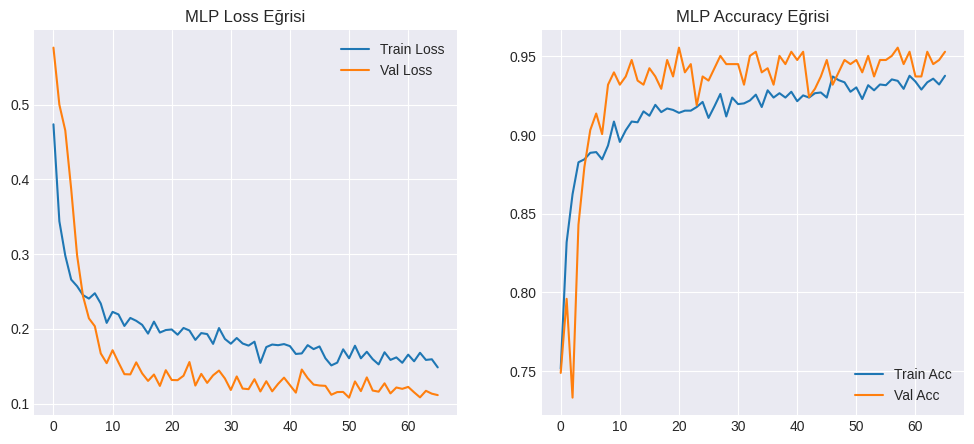

In [9]:
mlp_model, history = detector.train_mlp(X_train_s, y_train_sm.values, X_val_s, y_val.values, epochs=80, batch_size=32)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MLP Loss Eğrisi'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc'); plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('MLP Accuracy Eğrisi'); plt.legend()
plt.show()


---
## Bölüm 5: Tüm Gözetimli Modeller

Yukarıda çekirdek 4 model (Random Forest, XGBoost, SVM, MLP) ayrıntılı işlendi.
Bu bölümde 23 gözetimli modelin tamamı, aynı SMOTE'lu ve
ölçeklenmiş eğitim verisiyle eğitilir, sonraki bölümde hepsi birlikte değerlendirilir.

In [10]:
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression as _LR

detector.train_extra_trees(X_train_s, y_train_sm)
detector.train_xgbod(X_train_s, y_train_sm)
detector.train_gradient_boosting(X_train_s, y_train_sm)
detector.train_hist_gradient_boosting(X_train_s, y_train_sm)
detector.train_adaboost(X_train_s, y_train_sm)
detector.train_bagging(X_train_s, y_train_sm)
detector.train_decision_tree(X_train_s, y_train_sm)
detector.train_knn(X_train_s, y_train_sm)
detector.train_lsvc(X_train_s, y_train_sm)
detector.train_logistic_regression(X_train_s, y_train_sm)
detector.train_ridge(X_train_s, y_train_sm)
detector.train_sgd(X_train_s, y_train_sm)
detector.train_lda(X_train_s, y_train_sm)
detector.train_qda(X_train_s, y_train_sm)
detector.train_naive_bayes(X_train_s, y_train_sm)
detector.train_voting(X_train_s, y_train_sm)

detector.models['LightGBM'] = lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1).fit(X_train_s, y_train_sm)
detector.models['CatBoost'] = CatBoostClassifier(iterations=200, random_state=42, verbose=0).fit(X_train_s, y_train_sm)
detector.models['Stacking Ensemble'] = StackingClassifier(
    estimators=[(n, detector.models[n]) for n in ['RandomForest', 'LogisticRegression', 'KNN']],
    final_estimator=_LR(max_iter=500), cv=3, n_jobs=-1).fit(X_train_s, y_train_sm)

print(f"Eğitilen gözetimli model sayısı: {len(detector.models)}")
print(", ".join(detector.models.keys()))

Extra Trees eğitiliyor...
XGBOD eğitiliyor...
Gradient Boosting eğitiliyor...
HistGradientBoosting eğitiliyor...
AdaBoost eğitiliyor...
Bagging eğitiliyor...
Decision Tree eğitiliyor...
KNN (k=15) eğitiliyor...
Linear SVC eğitiliyor...
Logistic Regression eğitiliyor...
Ridge Classifier eğitiliyor...
SGD Classifier (log-loss) eğitiliyor...
LDA (Linear Discriminant Analysis) eğitiliyor...
QDA (Quadratic Discriminant Analysis) eğitiliyor...
Gaussian Naive Bayes eğitiliyor...
Voting Ensemble (soft) eğitiliyor...
Eğitilen gözetimli model sayısı: 23
RandomForest, XGBoost, SVM, MLP, ExtraTrees, XGBOD, GradientBoosting, HistGradientBoosting, AdaBoost, Bagging, DecisionTree, KNN, LSVC, LogisticRegression, Ridge, SGD, LDA, QDA, NaiveBayes, Voting Ensemble, LightGBM, CatBoost, Stacking Ensemble


---
## Bölüm 6: Değerlendirme

In [11]:
def _scores(model, name):
    import numpy as _np
    if name == 'MLP':
        prob = _np.asarray(model.predict(X_test_s, verbose=0)).ravel()
        return prob, (prob >= 0.5).astype(int)
    pred = model.predict(X_test_s)                       # modelin kendi ikili kararı
    if hasattr(model, 'predict_proba'):
        pr = _np.asarray(model.predict_proba(X_test_s))
        prob = pr[:, 1] if (pr.ndim == 2 and pr.shape[1] > 1) else pr.ravel()
    elif hasattr(model, 'decision_function'):
        prob = _np.asarray(model.decision_function(X_test_s)).ravel()
    else:
        prob = _np.asarray(pred, dtype=float)
    return prob, pred

demo_metrics = {}
for name, model in detector.models.items():
    prob, pred = _scores(model, name)
    demo_metrics[name] = compute_metrics(y_test.values, pred, prob)

results_df = metrics_table(demo_metrics, sort_by='AUC_PR')
display(results_df[BENCHMARK_METRICS].style.background_gradient(cmap='Blues').format('{:.4f}'))

,Accuracy,Precision,Recall,F1,MCC,AUC_ROC,AUC_PR
CatBoost,0.9565,0.9018,0.8938,0.8978,0.8702,0.9768,0.9503
Bagging,0.9584,0.9505,0.8496,0.8972,0.8734,0.9715,0.9450
XGBoost,0.9565,0.9167,0.8761,0.8959,0.8688,0.9742,0.9450
Stacking Ensemble,0.9603,0.9259,0.8850,0.9050,0.8803,0.9752,0.9443
LightGBM,0.9622,0.9346,0.8850,0.9091,0.8858,0.9692,0.9405
HistGradientBoosting,0.9527,0.8860,0.8938,0.8899,0.8598,0.9702,0.9391
RandomForest,0.9565,0.9245,0.8673,0.8950,0.8683,0.9655,0.9371
Voting Ensemble,0.9376,0.8390,0.8761,0.8571,0.8176,0.9697,0.9321
MLP,0.9301,0.7969,0.9027,0.8465,0.8040,0.9655,0.9258
GradientBoosting,0.9168,0.7851,0.8407,0.8120,0.7594,0.9613,0.9192


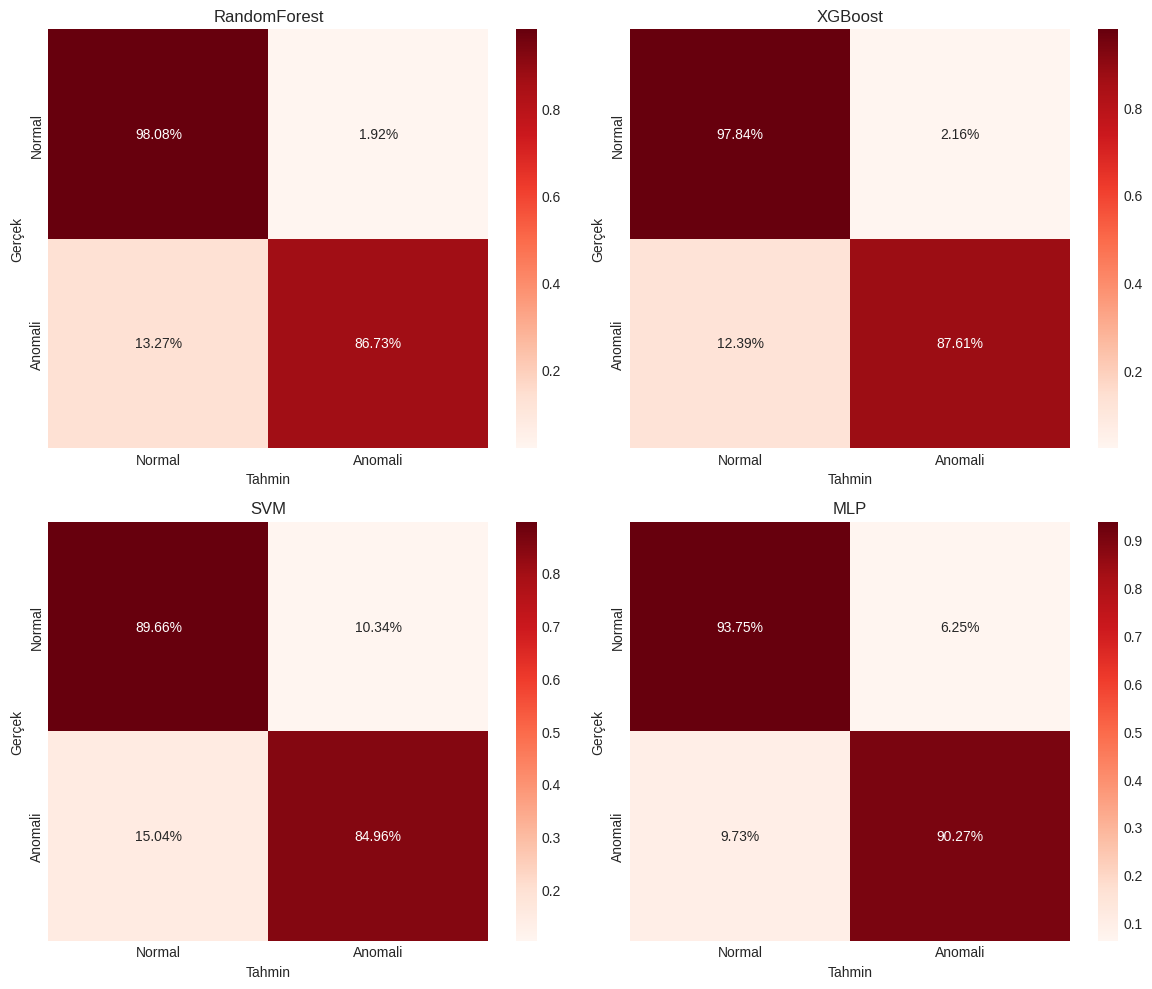

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10)); axes = axes.flatten()
for i, name in enumerate(['RandomForest', 'XGBoost', 'SVM', 'MLP']):
    m = detector.models[name]
    yp = (m.predict(X_test_s, verbose=0) >= 0.5).astype(int).flatten() if name == 'MLP' else m.predict(X_test_s)
    cm = confusion_matrix(y_test, yp, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Reds', ax=axes[i], xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
    axes[i].set_title(name); axes[i].set_xlabel('Tahmin'); axes[i].set_ylabel('Gerçek')
plt.tight_layout(); plt.show()

---
## Bölüm 7: ROC Eğrisi (Çekirdek Modeller)

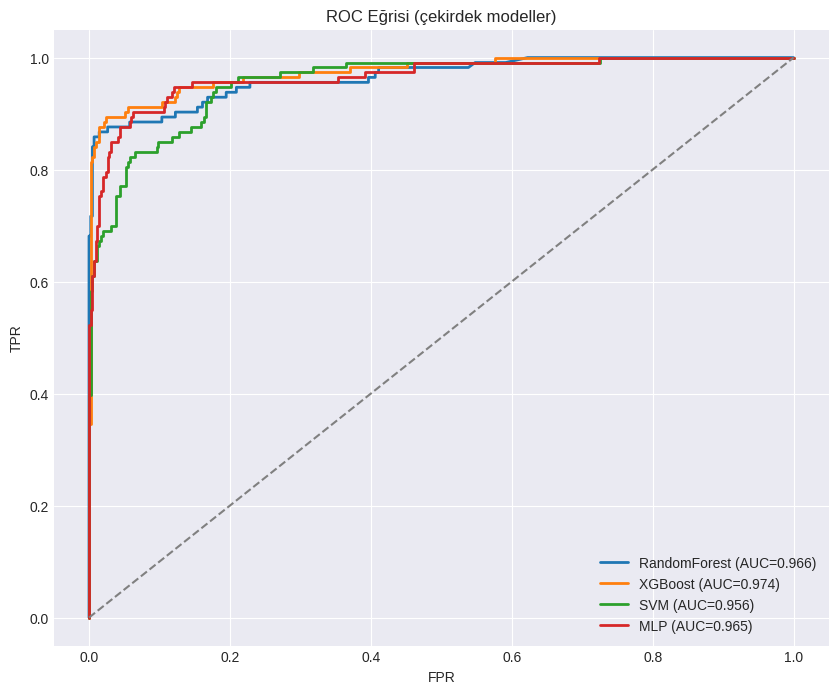

In [13]:
plt.figure(figsize=(10, 8))
for name in ['RandomForest', 'XGBoost', 'SVM', 'MLP']:
    model = detector.models[name]
    yp = model.predict(X_test_s, verbose=0).flatten() if name == 'MLP' else (model.predict_proba(X_test_s)[:,1] if hasattr(model,'predict_proba') else model.decision_function(X_test_s))
    fpr, tpr, _ = roc_curve(y_test, yp); ra = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={ra:.3f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Eğrisi (çekirdek modeller)'); plt.legend(loc='lower right')
plt.show()

---
## Bölüm 8: Kaydetme

Yukarıda models_trained.txt'deki 23 gözetimli modelin tamamı gösterim amacıyla eğitilip
test seti üzerinde değerlendirildi. Kaydedilen artefaktlar ve nihai karşılaştırma
`train_all_models.py` ile üretilir, notebook 06'da raporlanır.

---
## Bölüm 9: Derin Sıralı Modeller - Ham Telemetri Sinyali

Bu bölümdeki 2 derin model (CNN1D ve TCN) her segmentin ham telemetri sinyalini girdi alır. Veri `data/raw/segments.csv` dosyasından okunur, per-kanal standardize edilir, zaman-sıralı olarak L=256 uzunluğuna pad veya truncate edilir. Metrikler `reports/metrics/deep_sequence_comparison.json` dosyasına yazılır ve notebook 06da tabular modellerle birlikte sunulur.


In [14]:
import json, time
from sklearn.model_selection import train_test_split

SEG_PATH = '../data/raw/segments.csv'
SEQ_LEN = 256
_seg = pd.read_csv(SEG_PATH).sort_values(['segment', 'timestamp'], kind='stable')

_stats = _seg[_seg['train'] == 1].groupby('channel')['value'].agg(['mean', 'std'])
_gmean = _seg.loc[_seg['train'] == 1, 'value'].mean()
_gstd = _seg.loc[_seg['train'] == 1, 'value'].std() or 1.0

_meta = (_seg.groupby('segment')
         .agg(channel=('channel', 'first'), anomaly=('anomaly', 'first'), train=('train', 'first'))
         .reset_index().sort_values('segment'))
_grouped = {sid: g['value'].to_numpy() for sid, g in _seg.groupby('segment')}

Xseq = np.zeros((len(_meta), SEQ_LEN), dtype='float32')
for i, r in enumerate(_meta.itertuples(index=False)):
    if r.channel in _stats.index:
        mu, sd = _stats.loc[r.channel, 'mean'], _stats.loc[r.channel, 'std']
    else:
        mu, sd = _gmean, _gstd
    sd = sd if sd and sd > 1e-12 else 1.0
    vals = ((_grouped[r.segment].astype('float64') - mu) / sd)[:SEQ_LEN]   # uzunları kes
    Xseq[i, :len(vals)] = vals                                             # kısaları 0 ile pad et

yseq = _meta['anomaly'].to_numpy().astype(int)
_trm = _meta['train'].to_numpy() == 1
Xs_pool, ys_pool = Xseq[_trm], yseq[_trm]           
Xs_test, ys_test = Xseq[~_trm], yseq[~_trm]          
Xs_tr, Xs_val, ys_tr, ys_val = train_test_split(
    Xs_pool, ys_pool, test_size=0.15, random_state=42, stratify=ys_pool)

In [15]:
deep_detector = SupervisedAnomalyDetector(random_state=42)
_trainers = {
    'CNN1D': deep_detector.train_cnn1d, 'TCN': deep_detector.train_tcn,
}
_OUT = '../models/deep_sequence'; os.makedirs(_OUT, exist_ok=True)
deep_metrics = {}
for _name, _trainer in _trainers.items():
    try:
        _t0 = time.time()
        _trainer(Xs_tr, ys_tr, Xs_val, ys_val, epochs=40, batch_size=32)
        _model = deep_detector.models[_name]
        _prob = _model.predict(deep_detector._reshape_seq(Xs_test), verbose=0).ravel()
        _pred = (_prob >= 0.5).astype(int)
        _ims = (time.time() - _t0) * 1000 / len(Xs_test)
        deep_metrics[_name] = compute_metrics(ys_test, _pred, _prob, inf_time_ms=_ims)
        deep_detector.save_model(_name, os.path.join(_OUT, f'{_name.lower()}_model.keras'))
    except Exception as _e:
        print(f"  {_name}: ATLANDI ({type(_e).__name__}: {_e})")

os.makedirs('../reports/metrics', exist_ok=True)
with open('../reports/metrics/deep_sequence_comparison.json', 'w') as f:
    json.dump(deep_metrics, f, indent=2)
df_deep = metrics_table(deep_metrics, sort_by='AUC_PR')
display(df_deep[BENCHMARK_METRICS].style.background_gradient(cmap='Purples').format('{:.4f}'))


1D-CNN eğitiliyor...
Epoch 1/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8117 - loss: 0.4603 - val_accuracy: 0.3042 - val_loss: 0.7019
Epoch 2/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8493 - loss: 0.3865 - val_accuracy: 0.2167 - val_loss: 0.7374
Epoch 3/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8708 - loss: 0.3172 - val_accuracy: 0.2125 - val_loss: 0.7333
Epoch 4/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8826 - loss: 0.3033 - val_accuracy: 0.3667 - val_loss: 0.6956
Epoch 5/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8892 - loss: 0.2929 - val_accuracy: 0.8167 - val_loss: 0.6323
Epoch 6/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8951 - loss: 0.2730 - val_accuracy: 0.8167 - val_loss: 0.5584
Epoch 7/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9055 - loss: 0.2493 - val_accuracy: 0.8167 - val_loss: 0.5222
Epoch 8/40
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8988 - loss: 0.2578 - val_accur

,Accuracy,Precision,Recall,F1,MCC,AUC_ROC,AUC_PR
CNN1D,0.9187,0.8500,0.7522,0.7981,0.7497,0.9635,0.9105
TCN,0.9168,0.9059,0.6814,0.7778,0.7390,0.9690,0.9096
